# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [1]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [2]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [3]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Time Warping is necessary, or there would be falsely detected functional connection

## Creating ground truth with LIF neurons

In [56]:
from numpy import matlib
def toy_model_fr(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = features["bump_amp"] *np.exp(-((time_line-features["bump_center"])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def toy_model_fr_warping(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = features["bump_amp"] *np.exp(-((time_line[:, np.newaxis]- \
                                                      features["bump_center"][np.newaxis, :])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def generate_spike_train(fr, rep=1):
    if fr.ndim == 1:
        return np.random.poisson(lam=np.matlib.repmat(fr[:,np.newaxis],1,rep), size=None)
    else:
        return np.random.poisson(lam=np.matlib.repmat(fr,1,rep), size=None)

In [74]:
source = {"baseline": 0.02, "bump_center": np.nan, "bump_amp": 0.1, "bump_wid": 50}
target = {"baseline": 0.02, "bump_center": np.nan, "bump_amp": 0.1, "bump_wid": 50}
bump_center_mean = [225, 270]
bump_center_cov = np.array([[2500, 2000], [2000, 2500]])

nneuron = 1
nt = 500 # Say there are 500 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 1000 # 5000 trials in total

spike_trains_source = []
spike_trains_target = []
time_line = np.arange(nt)
bump_centers = np.random.multivariate_normal(bump_center_mean, bump_center_cov, size=ntrial)
source["bump_center"] = bump_centers[:, 0]
target["bump_center"] = bump_centers[:, 1]

for ineuron in range(nneuron):
    toy_model_fr_warping(source, time_line)
    spike_trains_source.append( generate_spike_train(source["fr"]) )
    toy_model_fr_warping(target, time_line)
    spike_trains_target.append( generate_spike_train(target["fr"]) )

Text(0.5, 1.0, 'ground truth firing rate')

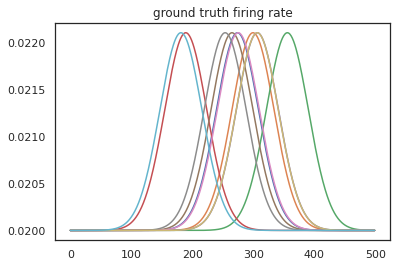

In [75]:
plt.plot(time_line, target["fr"][:, :10])
plt.title('ground truth firing rate')

## Single neuron level model without conditioning on peak timing

In [113]:
training_trials = np.array( [True]*int(ntrial*3/4)+[False]*int(ntrial*1/4) )
test_trials = np.logical_not(training_trials)

for output_spike_train in spike_trains_source:

    model = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
    model.add_effect("inhomogeneous_baseline", num=10)
    for input_spike_train in spike_trains_target:
        model.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=20, nonlinear=0.2)
    model.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
    model.test(test_trials)


## Population level model with time warping

# Sensitivity

Let's assume the synapses from neuron 1 to neuron 2 is excitatory. Spikes of neuron 1 have positive effect on neuron 2 firing rate. Note that we have 30 previous histories in the ground truth model. 

Text(0.5, 1.0, 'ground truth $\\gamma_{2,1,:}$')

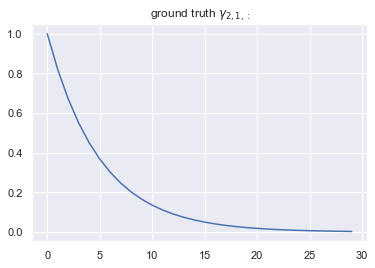

In [5]:
coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = np.exp(-time_line_coupling/5)
plt.plot(ground_truth_coupling_filter)
plt.title('ground truth $\gamma_{2,1,:}$')

In [6]:
log_lambda_coupling = GLM.conv(spike_neuron1, ground_truth_coupling_filter[:, np.newaxis])
log_lambda_coupling = log_lambda_coupling.reshape((nt, ntrial), order='F')
log_lambda_neuron2 = log_lambda_baseline + 0.5*log_lambda_stimulus[:,np.newaxis] + log_lambda_coupling
lambda_neuron2 = np.exp(log_lambda_neuron2)

In [7]:
lambda_neuron2.shape

(1000, 2000)

In [8]:
spike_neuron2 = np.random.poisson(lam=lambda_neuron2)

In [9]:
spike_neuron2.shape

(1000, 2000)

If we look at the log lambda of a given trial, we can see the firing rate of neuron 2 suddenly jump up when neuron 1 spikes. 

Text(0.5, 1.0, 'log firing rate of an example trial')

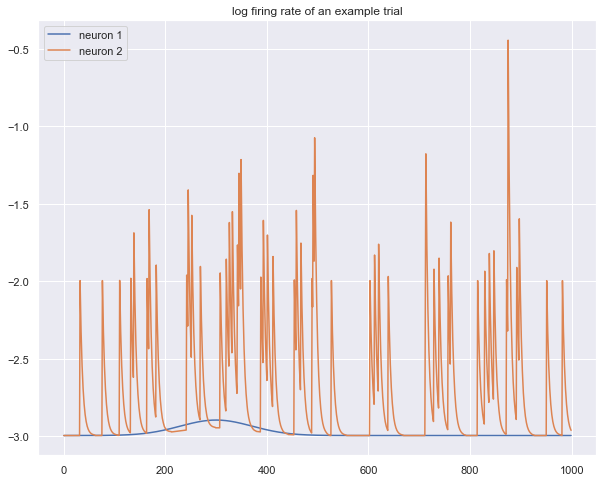

In [10]:
plt.subplots(figsize=(10,8))
plt.plot(log_lambda_neuron1, label='neuron 1')
plt.plot(log_lambda_neuron2[:,0], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

In [ ]:
W11 = 0.1
W12 = 0.1
